# Demo: Bounce Action $S_E$ — Four-Method Comparison

This notebook computes $S_E(T)$ for a fixed $(g_D, \mu/T, \lambda_{s,0})$ using four bounce-action methods and plots them on the same panel.

| Method | Potential | Algorithm |
|--------|-----------|-----------|
| **HT** | High-$T$ expansion | Espinosa tunnelling-potential ansatz |
| **Full** | Complete $J_B$ from table | Espinosa tunnelling-potential ansatz |
| **ODE + HT** | High-$T$ expansion | Direct ODE shooting + virial integral |
| **ODE + Full** | Complete $J_B$ from table | Direct ODE shooting + virial integral |

**Pipeline step:** $S_E$ is the third layer. Given an effective potential, the bounce solver finds the $O(3)$-symmetric bounce solution and integrates the action.

**Modules used:** `src/RGE/BounceSolFull_RGE.py`, `src/RGE/BounceSolHighT_RGE.py`, `src/RGE/BounceODE_RGE.py`

In [1]:
%load_ext autoreload
%autoreload 2

%run startup.py

startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


In [2]:
from src.RGE.BounceODE_RGE import BounceODEHighT, BounceODEFull

veff_obj        = veff.VeffRGE(vt_table_path="VT_integralNumeric.dat")
solver_ht       = bs_ht.BounceSolverHighT(veff=veff_obj)   # Espinosa HT
solver_full     = bs_full.BounceSolver(veff=veff_obj)       # Espinosa Full
solver_ode_ht   = BounceODEHighT(veff=veff_obj)             # ODE HT
solver_ode_full = BounceODEFull(veff=veff_obj)              # ODE Full
fopt_obj        = fopt.FOPTUtilities(veff_obj=veff_obj)     # for Hubble

/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/.venv/lib/python3.9/site-packages/scipy/ndimage/_filters.py:1856: RuntimeWarning: Mean of empty slice
  _nd_image.generic_filter(input, function, footprint, output, mode,


## 1. $S_E(T)$ — all methods

For a fixed $(g_D, \mu/T, \lambda_{s,0})$ we sweep $T$ and compute $S_E/T$ with all four methods. The nucleation condition
$$\frac{S_E(T_n)}{T_n} = 4\ln T_n + \frac{3}{2}\ln\frac{S_E/(2\pi T)}{T_n^2} - 4\ln H(T_n)$$
is shown as a dotted red curve; its crossing with each $S_E/T$ defines the method-specific $T_n$.

> **Note:** Full and ODE-Full take ~1 min/point. Reduce `n_T` for a quick test.

In [35]:
gD0   = 0.6
scale = np.pi
ls0   = 0
T_vals = np.concatenate((np.linspace(1e-5, 1e-2, 10), np.logspace(-2, np.log10(0.3), 40)))
n_T = len(T_vals)

methods = {
    "HT":       solver_ht,
   # "Full":     solver_full,
    "ODE+HT":   solver_ode_ht,
   # "ODE+Full": solver_ode_full,
}
S_results = {name: np.full(n_T, np.nan) for name in methods}

for name, slv in methods.items():
    for i, T in enumerate(tqdm(T_vals, desc=name)):
        try:
            S, _ = slv.SE(T, gD0, scale, ls0)
            S_results[name][i] = S
        except Exception:
            pass

HT:   8%|▊         | 4/50 [00:00<00:07,  6.54it/s]/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceSolHighT_RGE.py:201: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result = quad(integrand, 0, phi0, limit=5_000, epsrel=1e-6, epsabs=1e-6)[0]
ODE+HT: 100%|██████████| 50/50 [00:37<00:00,  1.34it/s]


In [44]:
# Save results in table T_vals vs S3/T_vals for each method. DIr is data/raw_data
import os


results_dir = "data/raw_data"
os.makedirs(results_dir, exist_ok=True)
results_path = os.path.join(results_dir, "bounce_action_comparison_HT_shooting.npz")
np.savez(results_path, T_vals=T_vals, **S_results)

# Save as .dat file for easier reading in Julia
dat_path = os.path.join(results_dir, "bounce_action_comparison_HT_shooting.dat")
with open(dat_path, "w") as f:
    header = "T\t" + "\t".join(S_results.keys()) + "\n"
    f.write(header)
    for i in range(n_T):
        line = f"{T_vals[i]:.6e}\t" + "\t".join(f"{S_results[name][i]:.6e}" for name in S_results) + "\n"
        f.write(line)   

In [ ]:
eps = 1e-300

# Hubble depends only on the T=0 minimum — identical for all methods
H_arr = np.array([
    fopt_obj.hubble(solver_ht.phi_min_Veff0(T, gD0, scale, ls0), T, gD0, scale, ls0)
    for T in T_vals
])

nuc_data = {}
for name, S_arr in S_results.items():
    ST  = S_arr / T_vals
    rhs = (4.0 * np.log(T_vals)
           + 1.5 * np.log(np.maximum(ST / (2.0 * np.pi), eps))
           - 4.0 * np.log(np.maximum(H_arr, eps)))
    nuc_data[name] = dict(ST=ST, rhs=rhs)

ODE+HT        Tn = 0.009657


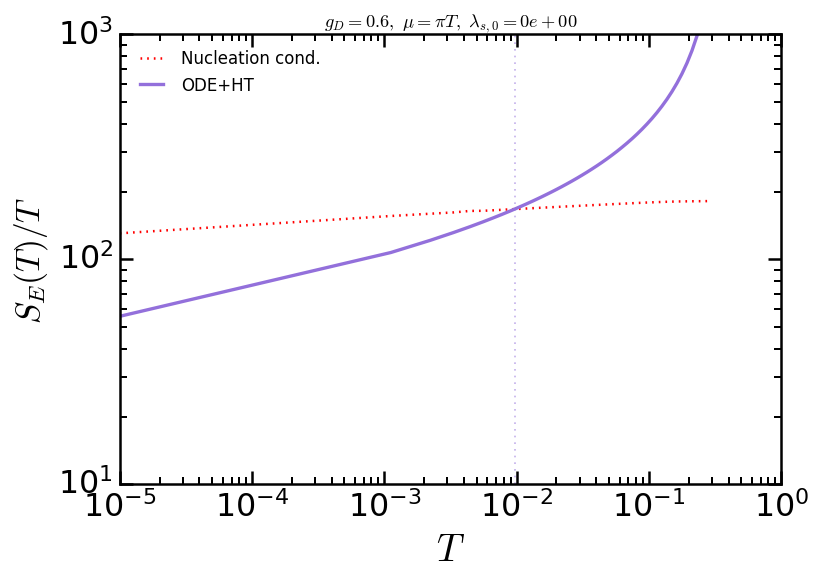

In [49]:
method_styles = {
    #"HT":       dict(color=ps.colors.get("HighT", "darkorange"), ls="-",  lw=2),
    # "Full":     dict(color=ps.colors.get("Full",  "steelblue"),  ls="-",  lw=2),
    "ODE+HT":   dict(color="mediumpurple",                        ls="-", lw=2),
    # "ODE+Full": dict(color="crimson",                             ls="--", lw=2),
}

fig, ax = new_figure(figsize=(7, 5), dpi=120)
fig.patch.set_facecolor('white')

# Nucleation condition (raw rhs from nuc_data["HT"])
ax.plot(T_vals, nuc_data["HT"]["rhs"],
        color="red", ls=":", lw=1.5, label="Nucleation cond.")

for name, style in method_styles.items():
    ST  = nuc_data[name]["ST"]
    rhs = nuc_data[name]["rhs"]

    ax.plot(T_vals, ST, label=name, **style)

    # Locate Tn from raw crossing
    y_cross = ST - rhs
    idx = np.where(np.sign(y_cross[:-1]) * np.sign(y_cross[1:]) < 0)[0]
    if idx.size:
        i  = idx[0]
        Tn = T_vals[i] - y_cross[i] * (T_vals[i+1] - T_vals[i]) / (y_cross[i+1] - y_cross[i])
        ax.axvline(Tn, color=style["color"], lw=1, alpha=0.55, ls=":")
        print(f"{name:12s}  Tn = {Tn:.6f}")

ps.apply_standard_formatting(
    ax, xlog=True, ylog=True,
    xlabel=r'$T$', ylabel=r'$S_E(T)/T$',
)
ax.set_title(fr'$g_D={gD0},\ \mu=\pi T,\ \lambda_{{s,0}}={ls0:.0e}$', fontsize=11)
ax.legend(loc="best", frameon=False, fontsize=10)
plt.tight_layout()

In [ ]:
gD0   = 0.6
scale = np.pi
ls0   = 0
T_eval = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

methods = {
    "HT":       solver_ht,
    "Full":     solver_full,
    "ODE+HT":   solver_ode_ht,
    "ODE+Full": solver_ode_full,
}

table = {}
for name, slv in methods.items():
    row = []
    for T in T_eval:
        try:
            S, _ = slv.SE(T, gD0, scale, ls0)
            row.append(S / T)
        except Exception:
            row.append(np.nan)
    table[name] = row

col_w  = 14
header = ["Method"] + [f"T = {T:.0e}" for T in T_eval]
print("  ".join(f"{h:>{col_w}}" for h in header))
print("-+-".join("-" * col_w for _ in header))
for name, vals in table.items():
    cells = [f"{name:>{col_w}}"] + [
        f"{v:>{col_w}.4g}" if np.isfinite(v) and v > 0 else f"{'—':>{col_w}}" for v in vals
    ]
    print("  ".join(cells))

/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceSolHighT_RGE.py:201: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result = quad(integrand, 0, phi0, limit=5_000, epsrel=1e-6, epsabs=1e-6)[0]


        Method       T = 1e-05       T = 1e-04       T = 1e-03       T = 1e-02       T = 1e-01
---------------+----------------+----------------+----------------+----------------+---------------
            HT           56.59           74.59           173.9           169.9           410.7
          Full           55.54           115.9           106.1           170.7           421.2
        ODE+HT           55.81           74.27           105.2           168.7           408.1
      ODE+Full           55.54           74.32           105.3           169.6           418.5


---
## 2. ODE + HT: sin fermión vs fermión con $y=0$

Comparación directa del método ODE + HT para mostrar que el modelo **sin fermión** y el modelo **con fermión pero $y=0$** son **diferentes**.

Con $y=0$ no hay acoplamiento de Yukawa — el fermión no adquiere masa del escalar — pero sigue contribuyendo al running de $g_D$ y a la masa de Debye del fotón oscuro ($\Pi_{A'} = \frac{5}{12}g_D^2 T^2$ vs $\frac{1}{3}g_D^2 T^2$ sin fermión). Estas diferencias se propagan al potencial efectivo y por tanto a la acción de rebote.

In [45]:
import importlib
import src.RGE.BounceODE_RGE as _bounce_mod
importlib.reload(_bounce_mod)
from src.RGE.BounceODE_RGE import BounceODEHighT_fermion

solver_ode_f0 = BounceODEHighT_fermion(veff=veff_ferm.VeffRGE_fermion(y0=0.0))

# Quick diagnostic on the first point before the full loop
_T_test = T_vals[len(T_vals) // 2]
try:
    _S, _phi = solver_ode_f0.SE(_T_test, gD0, scale, ls0)
    print(f"Diagnostic OK at T={_T_test:.4f}: S3={_S:.4e}")
except Exception as _e:
    print(f"Diagnostic FAILED at T={_T_test:.4f}: {type(_e).__name__}: {_e}")

SE_ode_f0 = np.full(len(T_vals), np.nan)
for i, T in enumerate(tqdm(T_vals, desc="ODE+HT fermión y=0")):
    try:
        S, _ = solver_ode_f0.SE(T, gD0, scale, ls0)
        SE_ode_f0[i] = S
    except Exception as e:
        if i < 3:
            print(f"  T={T:.2e}: {type(e).__name__}: {e}")
        pass

Diagnostic OK at T=0.0370: S3=9.2715e+00


ODE+HT fermión y=0: 100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


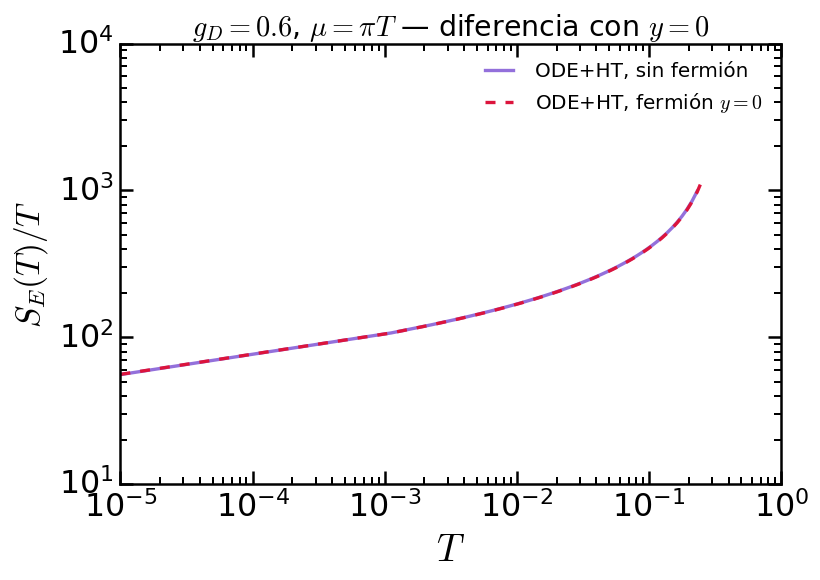

In [46]:
fig, ax = new_figure(figsize=(7, 5), dpi=120)
fig.patch.set_facecolor('white')

ax.plot(T_vals, S_results["ODE+HT"] / T_vals,
        color='mediumpurple', lw=2, label='ODE+HT, sin fermión')
ax.plot(T_vals, SE_ode_f0 / T_vals,
        color='crimson', lw=2, ls='--', label='ODE+HT, fermión $y=0$')

ps.apply_standard_formatting(
    ax, xlog=True, ylog=True,
    xlabel=r'$T$', ylabel=r'$S_E(T)/T$',
    title=fr'$g_D={gD0}$, $\mu=\pi T$ — diferencia con $y=0$',
)
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()

In [47]:
# Save data with fermion and without fermion in .dat file for easier reading in Julia
results_dir = "data/raw_data"
os.makedirs(results_dir, exist_ok=True)
dat_path = os.path.join(results_dir, "bounce_action_comparison_ODE_HT_fermion_y0.dat")
with open(dat_path, "w") as f:
    header = "T\tS_ODE_HT_no_fermion\tS_ODE_HT_fermion_y0\n"
    f.write(header)
    for i in range(n_T):
        line = f"{T_vals[i]:.6e}\t{S_results['ODE+HT'][i]:.6e}\t{SE_ode_f0[i]:.6e}\n"
        f.write(line)   

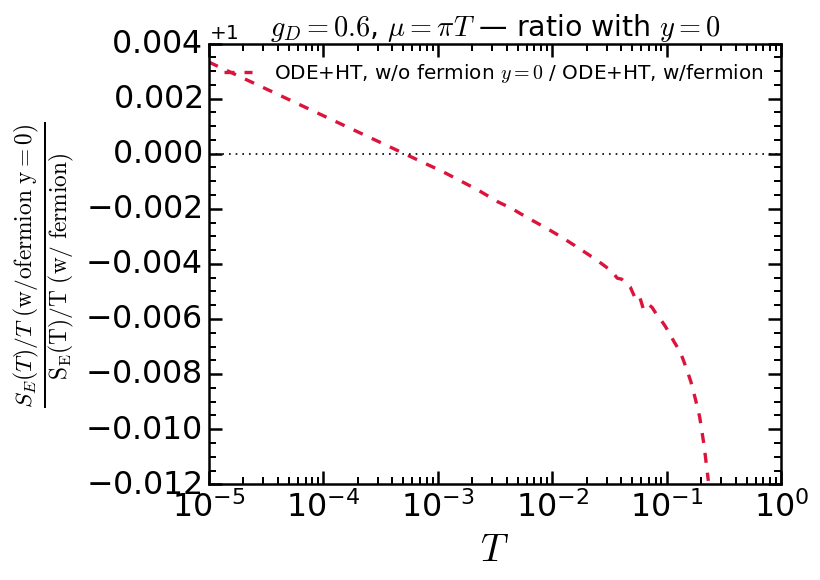

In [33]:
# Plot ratio of ODE+HT with fermion to ODE+HT without fermion
fig, ax = new_figure(figsize=(7, 5), dpi=120)
fig.patch.set_facecolor('white')
ratio = SE_ode_f0 / S_results["ODE+HT"]
ax.plot(T_vals, ratio, color='crimson', lw=2, ls='--', label='ODE+HT, w/o fermion $y=0$ / ODE+HT, w/fermion')
ax.axhline(1, color='k', lw=1, ls=':')
ps.apply_standard_formatting(
    ax, xlog=True, ylog=False,
    xlabel=r'$T$', ylabel=r'$\frac{S_E(T)/T\ \rm{(w/o fermion\ }y=0)}{S_E(T)/T\ \rm{(w/\ fermion)}}$',
    title=fr'$g_D={gD0}$, $\mu=\pi T$ — ratio with $y=0$'
)
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()      

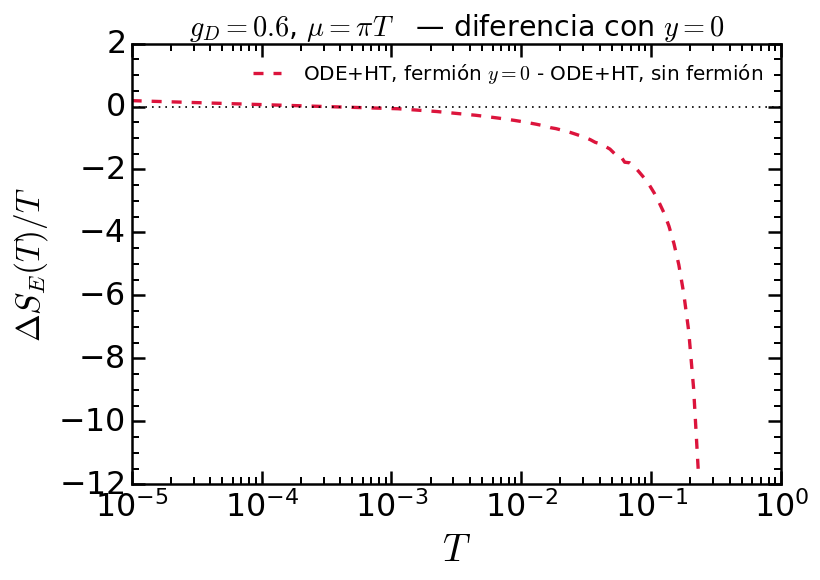

In [16]:
#plot difference in S3/T between ODE+HT with fermion and ODE+HT without fermion
fig, ax = new_figure(figsize=(7, 5), dpi=120)
fig.patch.set_facecolor('white')
difference = SE_ode_f0 / T_vals - S_results["ODE+HT"] / T_vals
ax.plot(T_vals, difference, color='crimson', lw=2, ls='--', label='ODE+HT, fermión $y=0$ - ODE+HT, sin fermión')
ax.axhline(0, color='k', lw=1       , ls=':')
ps.apply_standard_formatting(
    ax, xlog=True, ylog=False,
    xlabel=r'$T$', ylabel=r'$\Delta S_E(T)/T$',
    title=fr'$g_D={gD0}$, $\mu=\pi T$   — diferencia con $y=0$',
)
ax.legend(frameon=False, fontsize=12)
plt.tight_layout()      